# Image Deblurring and Ill-Conditioned Optimization

## Project 2 — Ill-Conditioned Optimization

This project studies image deblurring as an ill-conditioned inverse problem. 
We will examine how blur affects the conditioning of the optimization problem,
demonstrate the effect on a baseline optimizer, and test a regularization-based remedy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

np.random.seed(0)

print("Setup successful!")

Setup successful!


## Experiment 1: From a sharp image to a noisy observation

We create a 128 x 128 grayscale image containing a square, a disk, and two thin bars. Pixel intensities are normalized to the range 0 to 1. We then apply Gaussian blur with a standard deviation of 2 pixels and add Gaussian noise with a standard deviation of 0.03 (3% of the full intensity range) to the blurred image.

The original image is the known sharp reference; the blurred, noisy image is the observation that a later deblurring experiment will try to reconstruct.


In [2]:
# Bright shapes on a dark background provide clearly defined edges.
image_size = 128
sharp_image = np.full((image_size, image_size), 0.15, dtype=float)
sharp_image[24:72, 16:56] = 0.85

yy, xx = np.ogrid[:image_size, :image_size]
disk_mask = (xx - 94)**2 + (yy - 44)**2 <= 18**2
sharp_image[disk_mask] = 0.85

# Thin bars make the loss of fine detail easy to see.
sharp_image[88:92, 16:112] = 0.85
sharp_image[104:108, 16:112] = 0.85


In [3]:
blur_sigma = 2.0  # Gaussian blur standard deviation, in pixels.
noise_std = 0.03  # Noise standard deviation in normalized intensity units.

blurred_image = gaussian_filter(sharp_image, sigma=blur_sigma, mode="reflect")

# A local seed gives the same observation whenever this cell is rerun.
rng = np.random.default_rng(0)
noise = rng.normal(loc=0.0, scale=noise_std, size=blurred_image.shape)
noisy_image = blurred_image + noise

print(f"Image size: {image_size} x {image_size}")
print(f"Blur sigma: {blur_sigma:.1f} pixels; noise standard deviation: {noise_std:.2f}")


Image size: 128 x 128
Blur sigma: 2.0 pixels; noise standard deviation: 0.03


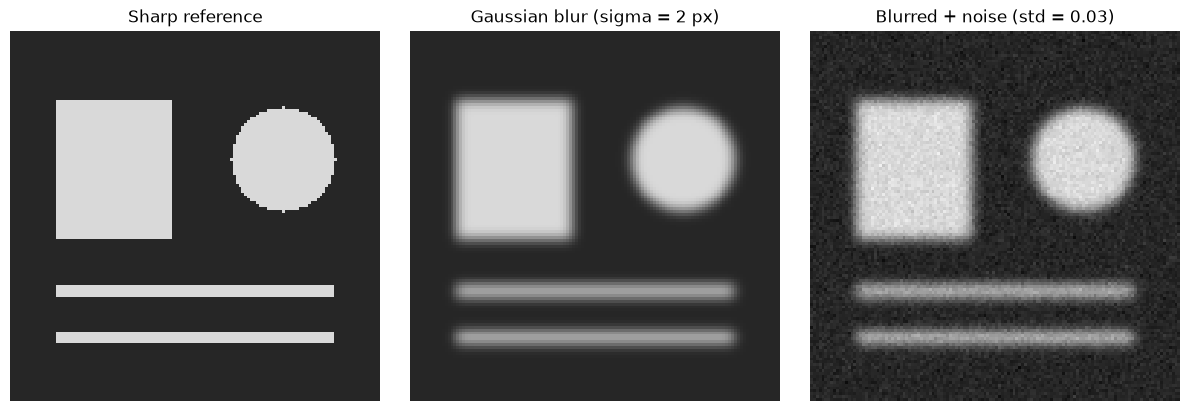

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")

images = [sharp_image, blurred_image, noisy_image]
titles = ["Sharp reference", "Gaussian blur (sigma = 2 px)", "Blurred + noise (std = 0.03)"]

for ax, image, title in zip(axes, images, titles):
    # Fixed limits keep brightness and contrast comparable across all panels.
    ax.imshow(image, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

plt.show()


### What the images show

- **Sharp reference:** The square, disk, and thin bars have abrupt boundaries and uniform interiors.
- **Gaussian blur:** Nearby pixels are averaged, spreading the boundaries into gradual transitions. Corners soften, and the thin bars lose contrast because their width is comparable to the blur scale.
- **Blurred + noise:** Small random intensity changes add visible grain to the blurred image. The edges remain soft; the grain does not restore the original detail.

All three panels use the same grayscale limits (0 to 1), so the differences come from the blur and noise rather than automatic display scaling. Later deblurring methods must recover sharp structure while avoiding amplification of this noise.
